# 🔌 Projeto: Engenharia de Dados em Big Data
## Análise da Matriz Energética Brasileira para Suporte à Expansão de Datacenters

**Disciplina:** Fundamentos de Dados e Analytics — Engenharia de Dados em Big Data  
**Universidade Presbiteriana Mackenzie**  
**Profs.:** Fabio Rossi Versolatto e Gustavo Moreira Calixto

---

### 📌 Contextualização

O Brasil vive a corrida global pela construção de **datacenters** para suportar a explosão da **Inteligência Artificial**. Datacenters são, em essência, **gigantescos consumidores de energia elétrica** — um único hyperscale pode consumir o equivalente a uma cidade de 100 mil habitantes. A escolha de onde instalar um datacenter depende criticamente de três fatores:

1. **Disponibilidade de energia** (capacidade instalada na região)  
2. **Matriz limpa** (renováveis = compromissos ESG/Net-Zero)  
3. **Estabilidade do fornecimento** (empreendimentos em operação vs. em construção)

Este projeto utiliza o dataset oficial **SIGA – Sistema de Informações de Geração** da **ANEEL** (Agência Nacional de Energia Elétrica), que contém **todos os empreendimentos de geração de energia elétrica do Brasil**, e aplica engenharia de dados em arquitetura **Medallion (Bronze → Silver → Gold)** com **MongoDB** + análise exploratória + Machine Learning.

### 🎯 Problema a ser resolvido

**Como prever, a partir das características de um empreendimento de geração de energia, em qual fase ele se encontra (Operação, Construção, Construção não iniciada) e qual sua potência fiscalizada esperada — fornecendo subsídio para decisões de localização de datacenters no Brasil?**

### 📊 Fonte de Dados

- **Nome:** SIGA – Sistema de Informações de Geração da ANEEL  
- **URL:** https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel  
- **Formato:** CSV (~7,5 MiB, dezenas de milhares de registros)  
- **Atualização:** mensal (última: abril/2026)  
- **Licença:** Open Data Commons Open Database License (ODbL) — uso aberto, gratuito  
- **23 colunas:** capacidade outorgada/fiscalizada, fase, fonte de combustível, UF, coordenadas, datas de operação, etc.

### 🛠️ Stack Tecnológica

| Camada | Tecnologia |
|---|---|
| Notebook / Execução | Google Colab |
| Ingestão | `requests`, `pandas` |
| Persistência | **MongoDB Atlas** (Free Tier) |
| Arquitetura | **Medallion** (Bronze / Silver / Gold) |
| EDA / Visualização | `pandas`, `matplotlib`, `seaborn`, `plotly` |
| Machine Learning | `scikit-learn` (Random Forest, XGBoost, KMeans) |
| Versionamento | GitHub |

---
# 🟫 ETAPA 1 — Processamento e Ingestão

**Objetivo:** capturar o dataset diretamente da ANEEL, persistir o **dado bruto** em MongoDB (camada **Bronze**) preservando a fidelidade da fonte.

## 1.1 — Instalação de dependências

In [1]:
# Pacotes essenciais (Colab já tem pandas, numpy, scikit-learn, matplotlib, seaborn)
!pip install -q pymongo dnspython plotly xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 20.3 MB/s eta 0:00:00


In [2]:
import os
import io
import requests
import pandas as pd
import numpy as np
from datetime import datetime
from pymongo import MongoClient, ASCENDING
from pymongo.errors import BulkWriteError
import warnings
warnings.filterwarnings('ignore')

print('✅ Imports prontos.')

✅ Imports prontos.


## 1.2 — Configuração do MongoDB Atlas

> **Como obter sua connection string gratuita:**  
> 1. Crie conta em https://www.mongodb.com/cloud/atlas/register  
> 2. Crie um cluster M0 (Free, 512 MB)  
> 3. Em **Database Access**, crie um usuário/senha  
> 4. Em **Network Access**, libere `0.0.0.0/0` (qualquer IP) — apenas para projeto acadêmico  
> 5. Em **Connect → Drivers**, copie a string `mongodb+srv://...`

No Colab, a forma **segura** é usar `userdata` (Secrets), em vez de colar a senha no código.

In [32]:
# === Conexão MongoDB Atlas (versão segura — Colab Secrets) ===
from google.colab import userdata

MONGO_URI = userdata.get('MONGO_URI')

assert MONGO_URI, '❌ Cadastre o secret MONGO_URI em Configurações → Secrets'

client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=10000)
client.admin.command('ping')
db = client['aneel_datacenters']
print('✅ Conectado ao MongoDB Atlas. Banco:', db.name)
print('📋 Coleções existentes:', db.list_collection_names())

✅ Conectado ao MongoDB Atlas. Banco: aneel_datacenters
📋 Coleções existentes: ['silver_siga', 'gold_uf_indicadores', 'bronze_siga', 'gold_predicoes_potencia']


## 1.3 — Ingestão (Download + carga na camada Bronze)

A camada **Bronze** armazena o dado **exatamente como veio da fonte**, com metadados de auditoria (data de ingestão, hash, etc.). Não fazemos transformação aqui — princípio fundamental da arquitetura Medallion.

In [4]:
URL_SIGA = ('https://dadosabertos.aneel.gov.br/dataset/'
            '6d90b77c-c5f5-4d81-bdec-7bc619494bb9/resource/'
            '11ec447d-698d-4ab8-977f-b424d5deee6a/'
            'download/siga-empreendimentos-geracao.csv')

print('⬇️  Baixando dataset SIGA da ANEEL...')
resp = requests.get(URL_SIGA, timeout=120)
resp.raise_for_status()
print(f'✅ Download OK: {len(resp.content)/1024/1024:.2f} MiB')

# O CSV da ANEEL usa separador ; e encoding latin-1 (padrão BR)
df_raw = pd.read_csv(
    io.BytesIO(resp.content),
    sep=';',
    encoding='latin-1',
    dtype=str,           # tudo como string -> Bronze preserva o original
    on_bad_lines='skip'
)
print(f'📊 Shape bruto: {df_raw.shape}')
df_raw.head(3)

⬇️  Baixando dataset SIGA da ANEEL...
✅ Download OK: 7.46 MiB
📊 Shape bruto: (25417, 23)


,DatGeracaoConjuntoDados,NomEmpreendimento,IdeNucleoCEG,CodCEG,SigUFPrincipal,SigTipoGeracao,DscFaseUsina,DscOrigemCombustivel,DscFonteCombustivel,DscTipoOutorga,...,MdaPotenciaFiscalizadaKw,MdaGarantiaFisicaKw,IdcGeracaoQualificada,NumCoordNEmpreendimento,NumCoordEEmpreendimento,DatInicioVigencia,DatFimVigencia,DscPropriRegimePariticipacao,DscSubBacia,DscMuninicpios
0,2026-04-01,E,000008,PCH.PH.MG.000008-6.1,MG,PCH,Operação,Hídrica,Potencial hidráulico,Autorização,...,1400,",00",Não,"-20,12479858","-43,87020250",2000-07-07,2030-07-07,100% para ANGLOGOLD ASHANTI CORREGO DO SITIO M...,41 - Das Velhas - Sao Francisco,Nova Lima - MG
1,2026-04-01,F,000009,PCH.PH.MG.000009-4.1,MG,PCH,Operação,Hídrica,Potencial hidráulico,Autorização,...,3972,",00",Não,"-20,13187300","-43,87693500",2000-07-07,2030-07-07,100% para ANGLOGOLD ASHANTI CORREGO DO SITIO M...,41 - Das Velhas - Sao Francisco,Nova Lima - MG
2,2026-04-01,G,000010,PCH.PH.MG.000010-8.1,MG,PCH,Operação,Hídrica,Potencial hidráulico,Autorização,...,1440,",00",Não,"-20,13754468","-43,89192620",2000-08-31,2030-08-31,100% para ANGLOGOLD ASHANTI CORREGO DO SITIO M...,41 - Das Velhas - Sao Francisco,Nova Lima - MG


In [5]:
# Carga na coleção Bronze (idempotente: limpa antes para reprocessamento)
col_bronze = db['bronze_siga']
col_bronze.drop()  # facilita re-execução do notebook

ingest_ts = datetime.utcnow()
registros = df_raw.to_dict(orient='records')
for r in registros:
    r['_ingest_ts'] = ingest_ts
    r['_source']    = 'ANEEL/SIGA'
    r['_source_url']= URL_SIGA

BATCH = 5000
for i in range(0, len(registros), BATCH):
    col_bronze.insert_many(registros[i:i+BATCH], ordered=False)

# índice por UF acelera consultas exploratórias
col_bronze.create_index([('SigUFPrincipal', ASCENDING)])

print(f'✅ Bronze carregada: {col_bronze.estimated_document_count():,} documentos.')

✅ Bronze carregada: 25,417 documentos.


In [6]:
# Verificação rápida — amostra do que foi armazenado
for d in col_bronze.find().limit(2):
    for k, v in d.items():
        print(f'  {k}: {v}')
    print('-'*60)

  _id: 69f101b7f5e5b5dadddc7a91
  DatGeracaoConjuntoDados: 2026-04-01
  NomEmpreendimento: E
  IdeNucleoCEG: 000008
  CodCEG: PCH.PH.MG.000008-6.1
  SigUFPrincipal: MG
  SigTipoGeracao: PCH
  DscFaseUsina: Operação
  DscOrigemCombustivel: Hídrica
  DscFonteCombustivel: Potencial hidráulico
  DscTipoOutorga: Autorização
  NomFonteCombustivel: Potencial hidráulico
  DatEntradaOperacao: 1953-11-20
  MdaPotenciaOutorgadaKw: 1400,00
  MdaPotenciaFiscalizadaKw: 1400
  MdaGarantiaFisicaKw: ,00
  IdcGeracaoQualificada: Não
  NumCoordNEmpreendimento: -20,12479858
  NumCoordEEmpreendimento: -43,87020250
  DatInicioVigencia: 2000-07-07
  DatFimVigencia: 2030-07-07
  DscPropriRegimePariticipacao: 100% para ANGLOGOLD ASHANTI CORREGO DO SITIO MINERACAO S.A. (APE)
  DscSubBacia:  41 - Das Velhas - Sao Francisco
  DscMuninicpios: Nova Lima - MG
  _ingest_ts: 2026-04-28 18:51:34.740000
  _source: ANEEL/SIGA
  _source_url: https://dadosabertos.aneel.gov.br/dataset/6d90b77c-c5f5-4d81-bdec-7bc619494bb9/re

✅ **Etapa 1 concluída.** Dado bruto preservado, auditável e versionado em MongoDB.

---
# 🟪 ETAPA 2 — Análise Exploratória e Limpeza (Silver + Gold)

**Objetivo:** transformar Bronze → **Silver** (dados limpos, tipados, normalizados) e Silver → **Gold** (agregados prontos para análise/ML).

## 2.1 — Bronze → Silver: limpeza e tipagem

Operações na Silver:
- Conversão de tipos (texto → numérico/data/coordenada)
- Padronização de strings (uppercase, strip)
- Tratamento de nulos
- Remoção de duplicatas pela chave natural `CodCEG`
- Validação de regras de negócio (potências > 0, UF válida, etc.)

In [7]:
# Carregamos a Bronze de volta para um DataFrame
df = pd.DataFrame(list(col_bronze.find({}, {'_id': 0, '_ingest_ts': 0,
                                            '_source': 0, '_source_url': 0})))
print('Shape Bronze:', df.shape)
df.dtypes.head(10)

Shape Bronze: (25417, 23)


,0
DatGeracaoConjuntoDados,object
NomEmpreendimento,object
IdeNucleoCEG,object
CodCEG,object
SigUFPrincipal,object
SigTipoGeracao,object
DscFaseUsina,object
DscOrigemCombustivel,object
DscFonteCombustivel,object
DscTipoOutorga,object


In [19]:
def to_float_br(s):
    """Converte string numérica BR ('1.234,56') -> float."""
    if pd.isna(s) or s in ('', '-', 'N/A'):
        return np.nan
    return float(str(s).replace('.', '').replace(',', '.'))

# Updated function to infer date format, as the original data is YYYY-MM-DD
def to_date_universal(s):
    return pd.to_datetime(s, errors='coerce')

df_silver = df.copy()

# Numéricos
for c in ['MdaPotenciaOutorgadaKw', 'MdaPotenciaFiscalizadaKw', 'MdaGarantiaFisicaKw']:
    df_silver[c] = df_silver[c].apply(to_float_br)

# Coordenadas (vêm como '23°32\'S' ou '-23.5' — tentamos ambos)
def parse_coord(s):
    if pd.isna(s) or s == '':
        return np.nan
    s = str(s).replace(',', '.').replace(' ', '')
    try:
        return float(s)
    except ValueError:
        return np.nan

df_silver['lat'] = df_silver['NumCoordNEmpreendimento'].apply(parse_coord)
df_silver['lon'] = df_silver['NumCoordEEmpreendimento'].apply(parse_coord)

# Datas - Using the updated universal date parser
for c in ['DatEntradaOperacao', 'DatInicioVigencia', 'DatFimVigencia', 'DatGeracaoConjuntoDados']:
    df_silver[c] = to_date_universal(df_silver[c])

# Padronização textual
txt_cols = ['SigUFPrincipal', 'SigTipoGeracao', 'DscFaseUsina',
            'DscOrigemCombustivel', 'DscFonteCombustivel',
            'NomFonteCombustivel', 'DscTipoOutorga']
for c in txt_cols:
    df_silver[c] = df_silver[c].astype(str).str.strip().str.upper()
    df_silver[c] = df_silver[c].replace({'NAN': np.nan, '': np.nan})

# Deduplicação
antes = len(df_silver)
df_silver = df_silver.drop_duplicates(subset=['CodCEG'], keep='last')
print(f'🧹 Duplicatas removidas: {antes - len(df_silver)}')

# Filtros de qualidade
df_silver = df_silver[df_silver['MdaPotenciaOutorgadaKw'] > 0]
df_silver = df_silver[df_silver['SigUFPrincipal'].str.len() == 2]

print(f'✅ Silver pronta: {df_silver.shape}')
df_silver[['NomEmpreendimento','SigUFPrincipal','SigTipoGeracao',
           'DscFaseUsina','MdaPotenciaOutorgadaKw',
           'DscFonteCombustivel']].head()

🧹 Duplicatas removidas: 3
✅ Silver pronta: (25414, 25)


,NomEmpreendimento,SigUFPrincipal,SigTipoGeracao,DscFaseUsina,MdaPotenciaOutorgadaKw,DscFonteCombustivel
0,E,MG,PCH,OPERAÇÃO,1400.0,POTENCIAL HIDRÁULICO
1,F,MG,PCH,OPERAÇÃO,3972.0,POTENCIAL HIDRÁULICO
2,G,MG,PCH,OPERAÇÃO,1440.0,POTENCIAL HIDRÁULICO
3,14 de Julho,RS,UHE,OPERAÇÃO,100000.0,POTENCIAL HIDRÁULICO
4,Abaúna,RS,CGH,OPERAÇÃO,720.0,POTENCIAL HIDRÁULICO


In [12]:
# Persistir Silver no MongoDB
col_silver = db['silver_siga']
col_silver.drop()

# Convert datetime columns to ISO 8601 strings (MongoDB extended JSON default)
datetime_cols = ['DatGeracaoConjuntoDados', 'DatEntradaOperacao', 'DatInicioVigencia', 'DatFimVigencia']
for col in datetime_cols:
    if col in df_silver.columns:
        # Apply isoformat to each non-NaT datetime object, convert NaT to None
        df_silver[col] = df_silver[col].apply(lambda x: x.isoformat(timespec='milliseconds') if pd.notna(x) else None)

col_silver.insert_many(df_silver.to_dict(orient='records'))
col_silver.create_index([('SigUFPrincipal', 1), ('DscFaseUsina', 1)])
col_silver.create_index([('SigTipoGeracao', 1)])
print(f'✅ Silver gravada: {col_silver.estimated_document_count():,} documentos.')

✅ Silver gravada: 25,414 documentos.


## 2.2 — Análise Exploratória de Dados (EDA)

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 5)

# Estatísticas descritivas
print('=== Resumo numérico (kW) ===')
print(df_silver[['MdaPotenciaOutorgadaKw','MdaPotenciaFiscalizadaKw','MdaGarantiaFisicaKw']]
      .describe().round(2))

print('\n=== Nulos por coluna (%) ===')
print((df_silver.isna().mean()*100).round(2).sort_values(ascending=False).head(10))

=== Resumo numérico (kW) ===
       MdaPotenciaOutorgadaKw  MdaPotenciaFiscalizadaKw  MdaGarantiaFisicaKw
count                25414.00                  25414.00             25414.00
mean                 13269.96                   8592.87              4047.90
std                 123403.62                 121957.04             74861.36
min                      0.01                      0.00                 0.00
25%                      1.00                      1.00                 0.00
50%                      1.00                      1.00                 0.00
75%                   2000.00                     81.75                 0.00
max               11233100.00               11233100.00           7750800.00

=== Nulos por coluna (%) ===
DatGeracaoConjuntoDados    100.00
DatInicioVigencia          100.00
DatFimVigencia             100.00
DatEntradaOperacao         100.00
DscSubBacia                 94.27
IdcGeracaoQualificada       62.79
NomEmpreendimento            0.00
CodCEG    

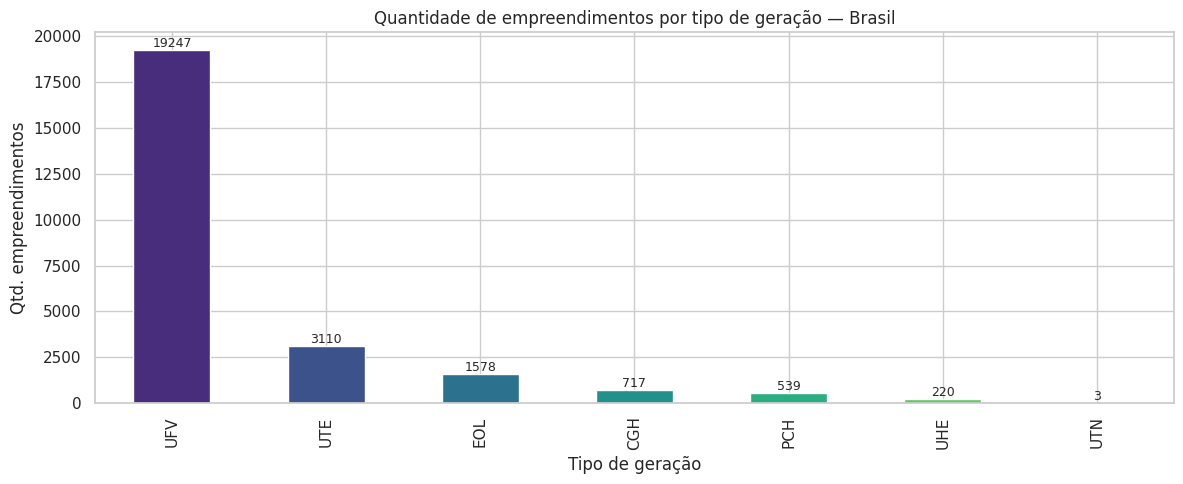

In [14]:
# Distribuição por tipo de geração
tipo_count = df_silver['SigTipoGeracao'].value_counts()
ax = tipo_count.plot(kind='bar', color=sns.color_palette('viridis', len(tipo_count)))
ax.set_title('Quantidade de empreendimentos por tipo de geração — Brasil')
ax.set_xlabel('Tipo de geração'); ax.set_ylabel('Qtd. empreendimentos')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

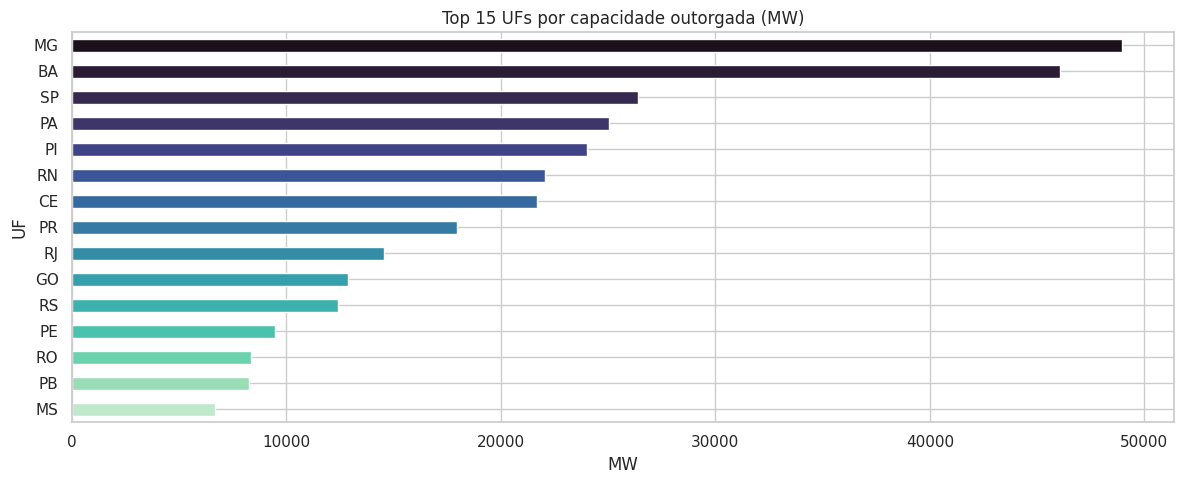

In [15]:
# Capacidade instalada (MW) por UF — Top 15
cap_uf = (df_silver.groupby('SigUFPrincipal')['MdaPotenciaOutorgadaKw']
          .sum().div(1000).sort_values(ascending=False).head(15))
ax = cap_uf.plot(kind='barh', color=sns.color_palette('mako', len(cap_uf)))
ax.invert_yaxis()
ax.set_title('Top 15 UFs por capacidade outorgada (MW)')
ax.set_xlabel('MW'); ax.set_ylabel('UF')
plt.tight_layout(); plt.show()

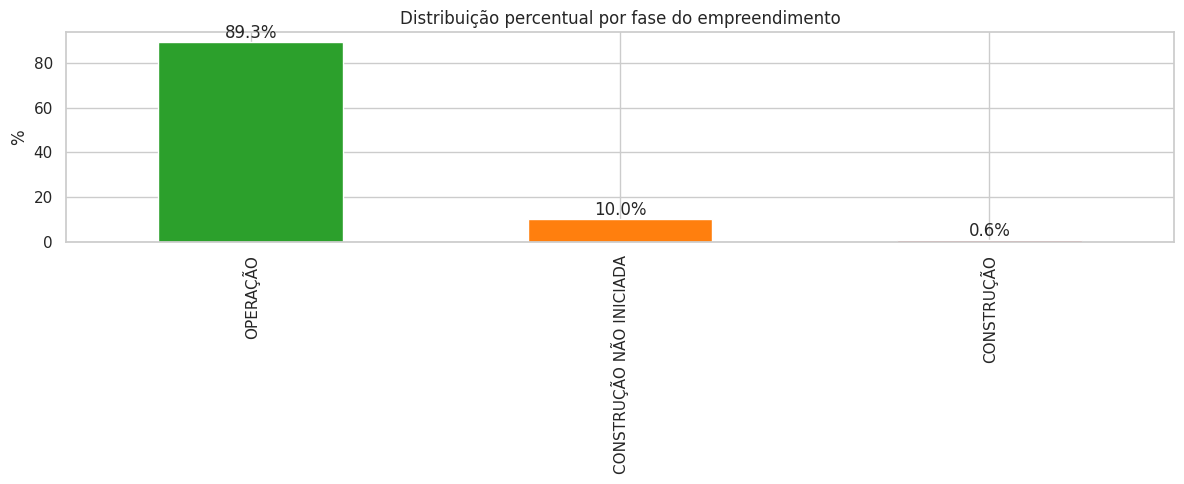

In [16]:
# Fase das usinas (operação x construção x não iniciada)
fase = df_silver['DscFaseUsina'].value_counts(normalize=True).mul(100).round(2)
ax = fase.plot(kind='bar', color=['#2ca02c','#ff7f0e','#d62728','#7f7f7f'])
ax.set_title('Distribuição percentual por fase do empreendimento')
ax.set_ylabel('%'); ax.set_xlabel('')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()

In [17]:
# Mapa interativo dos empreendimentos em operação
df_mapa = df_silver.dropna(subset=['lat','lon'])
df_mapa = df_mapa[df_mapa['lat'].between(-35,5) & df_mapa['lon'].between(-75,-30)]
df_mapa = df_mapa[df_mapa['DscFaseUsina'] == 'OPERAÇÃO'].sample(
    min(3000, len(df_mapa)), random_state=42)

fig = px.scatter_mapbox(
    df_mapa, lat='lat', lon='lon',
    color='SigTipoGeracao',
    size='MdaPotenciaOutorgadaKw',
    hover_name='NomEmpreendimento',
    hover_data={'SigUFPrincipal':True,'MdaPotenciaOutorgadaKw':':.0f'},
    zoom=3, height=600,
    title='Empreendimentos em operação (amostra) — geolocalização x potência'
)
fig.update_layout(mapbox_style='open-street-map', margin=dict(r=0,t=30,l=0,b=0))
fig.show()

In [30]:
# Evolução temporal — entrada em operação por ano e fonte
df_tempo = df_silver.dropna(subset=['DatEntradaOperacao']).copy()
df_tempo['ano'] = df_tempo['DatEntradaOperacao'].dt.year
df_tempo = df_tempo[df_tempo['ano'].between(2000, 2026)]

evol = (df_tempo.groupby(['ano','SigTipoGeracao'])['MdaPotenciaOutorgadaKw']
        .sum().div(1000).reset_index())
fig = px.area(evol, x='ano', y='MdaPotenciaOutorgadaKw', color='SigTipoGeracao',
              title='Evolução da capacidade instalada (MW) por fonte (2000–2026)',
              labels={'MdaPotenciaOutorgadaKw':'MW outorgados'})
fig.show()

## 2.3 — Silver → Gold: agregações para análise de viabilidade de datacenters

Construímos um **mart Gold** por UF com indicadores prontos para a equipe de planejamento de datacenters:

In [21]:
# Classificação "limpa" da fonte
renovavel = ['HÍDRICA','EÓLICA','RADIAÇÃO SOLAR','BIOMASSA','MARÉS']
df_silver['eh_renovavel'] = df_silver['DscOrigemCombustivel'].isin(renovavel)

gold_uf = df_silver.groupby('SigUFPrincipal').agg(
    qtd_empreendimentos    = ('CodCEG', 'count'),
    capacidade_total_MW    = ('MdaPotenciaOutorgadaKw',
                              lambda x: round(x.sum()/1000, 2)),
    capacidade_operacao_MW = ('MdaPotenciaFiscalizadaKw',
                              lambda x: round(x.fillna(0).sum()/1000, 2)),
    pct_renovavel          = ('eh_renovavel',
                              lambda x: round(x.mean()*100, 2)),
    qtd_em_operacao        = ('DscFaseUsina',
                              lambda x: (x=='OPERAÇÃO').sum()),
    qtd_em_construcao      = ('DscFaseUsina',
                              lambda x: (x=='CONSTRUÇÃO').sum()),
).reset_index().sort_values('capacidade_total_MW', ascending=False)

gold_uf['indice_atratividade'] = (
    0.5 * (gold_uf['capacidade_total_MW'] / gold_uf['capacidade_total_MW'].max()) +
    0.3 * (gold_uf['pct_renovavel'] / 100) +
    0.2 * (gold_uf['qtd_em_construcao'] / gold_uf['qtd_em_construcao'].max())
).round(3)

# Persistir camada Gold
col_gold = db['gold_uf_indicadores']
col_gold.drop()
col_gold.insert_many(gold_uf.to_dict(orient='records'))
print('✅ Gold por UF gravada.')

gold_uf.head(10)

✅ Gold por UF gravada.


,SigUFPrincipal,qtd_empreendimentos,capacidade_total_MW,capacidade_operacao_MW,pct_renovavel,qtd_em_operacao,qtd_em_construcao,indice_atratividade
10,MG,1462,48934.47,25166.35,24.42,938,8,0.623
4,BA,1171,46075.74,21917.34,49.70,616,16,0.720
25,SP,1194,26405.17,25451.54,32.16,1173,5,0.398
13,PA,13202,25050.84,22849.58,0.22,13200,2,0.269
16,PI,585,24017.52,7078.40,26.15,227,7,0.368
19,RN,652,22055.86,13130.63,56.90,434,19,0.515
5,CE,617,21704.23,6608.16,27.07,207,5,0.334
17,PR,320,17946.79,17674.25,64.06,299,5,0.407
18,RJ,228,14557.48,12676.44,23.68,218,4,0.245
8,GO,285,12860.50,8225.60,36.49,184,4,0.266


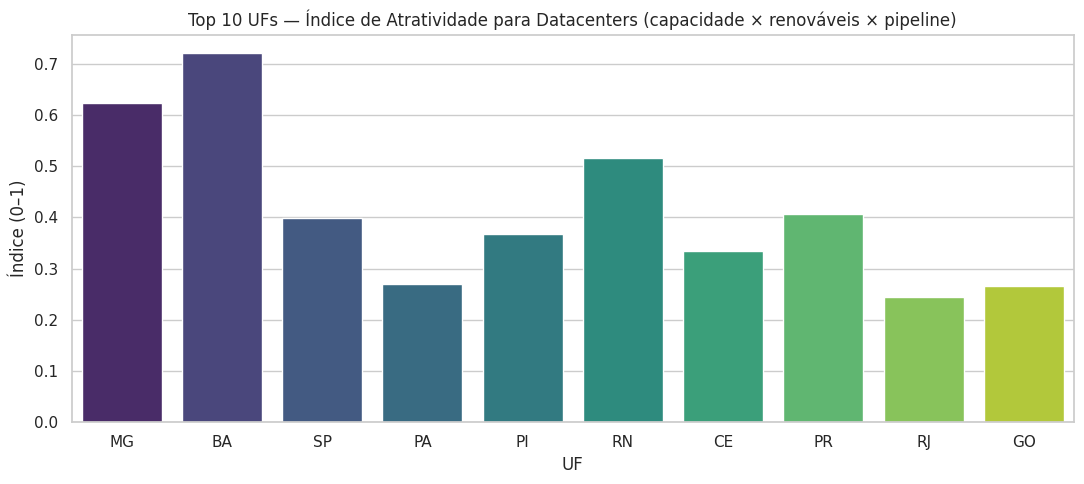

In [22]:
# Visualização do índice de atratividade (proxy para localização de datacenters)
top10 = gold_uf.head(10)
fig, ax = plt.subplots(figsize=(11,5))
sns.barplot(data=top10, x='SigUFPrincipal', y='indice_atratividade',
            palette='viridis', ax=ax)
ax.set_title('Top 10 UFs — Índice de Atratividade para Datacenters '
             '(capacidade × renováveis × pipeline)')
ax.set_xlabel('UF'); ax.set_ylabel('Índice (0–1)')
plt.tight_layout(); plt.show()

✅ **Etapa 2 concluída.** Bronze → Silver → Gold persistidas no MongoDB. EDA realizada.

---
# 🟦 ETAPA 3 — Aplicação de Machine Learning

Treinamos **dois modelos**:

1. **Classificação** — prever a *fase* da usina (Operação / Construção / Construção não iniciada)  
   → **Random Forest** vs **XGBoost**
2. **Regressão** — prever a *potência fiscalizada (kW)*  
   → **Random Forest Regressor**

In [23]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, mean_absolute_error,
                              r2_score, mean_squared_error)
from xgboost import XGBClassifier

# === Preparação do dataset de modelagem ===
df_ml = df_silver.dropna(subset=['DscFaseUsina','MdaPotenciaOutorgadaKw',
                                  'SigTipoGeracao','SigUFPrincipal',
                                  'DscOrigemCombustivel']).copy()

# manter as 3 fases mais frequentes
top_fases = df_ml['DscFaseUsina'].value_counts().head(3).index
df_ml = df_ml[df_ml['DscFaseUsina'].isin(top_fases)]
print('Distribuição da target:')
print(df_ml['DscFaseUsina'].value_counts())

Distribuição da target:
DscFaseUsina
OPERAÇÃO                   22704
CONSTRUÇÃO NÃO INICIADA     2550
CONSTRUÇÃO                   160
Name: count, dtype: int64


In [24]:
# === Feature engineering ===
df_ml['ano_operacao'] = df_ml['DatEntradaOperacao'].dt.year.fillna(2030)
df_ml['log_potencia'] = np.log1p(df_ml['MdaPotenciaOutorgadaKw'])
df_ml['eh_renovavel_int'] = df_ml['eh_renovavel'].astype(int)

features_cat = ['SigTipoGeracao','SigUFPrincipal','DscOrigemCombustivel','DscTipoOutorga']
features_num = ['MdaPotenciaOutorgadaKw','log_potencia','ano_operacao','eh_renovavel_int']

# Encoding
encoders = {}
for c in features_cat:
    le = LabelEncoder()
    df_ml[c+'_enc'] = le.fit_transform(df_ml[c].astype(str))
    encoders[c] = le

X = df_ml[[c+'_enc' for c in features_cat] + features_num]
y_class = LabelEncoder().fit_transform(df_ml['DscFaseUsina'])
print('X shape:', X.shape)

X shape: (25414, 8)


## 3.1 — Modelo de Classificação

In [25]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y_class, test_size=0.25,
                                           random_state=42, stratify=y_class)

rf = RandomForestClassifier(n_estimators=300, max_depth=15,
                            class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_tr, y_tr)
pred_rf = rf.predict(X_te)

xgb = XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.1,
                    eval_metric='mlogloss', n_jobs=-1, random_state=42)
xgb.fit(X_tr, y_tr)
pred_xgb = xgb.predict(X_te)

print(f'Random Forest — Accuracy: {accuracy_score(y_te, pred_rf):.4f}')
print(f'XGBoost       — Accuracy: {accuracy_score(y_te, pred_xgb):.4f}')
print('\n=== Classification report (XGBoost) ===')
print(classification_report(y_te, pred_xgb))

Random Forest — Accuracy: 0.9942
XGBoost       — Accuracy: 0.9942

=== Classification report (XGBoost) ===
              precision    recall  f1-score   support

           0       0.67      0.45      0.54        40
           1       0.97      0.98      0.98       638
           2       1.00      1.00      1.00      5676

    accuracy                           0.99      6354
   macro avg       0.88      0.81      0.84      6354
weighted avg       0.99      0.99      0.99      6354



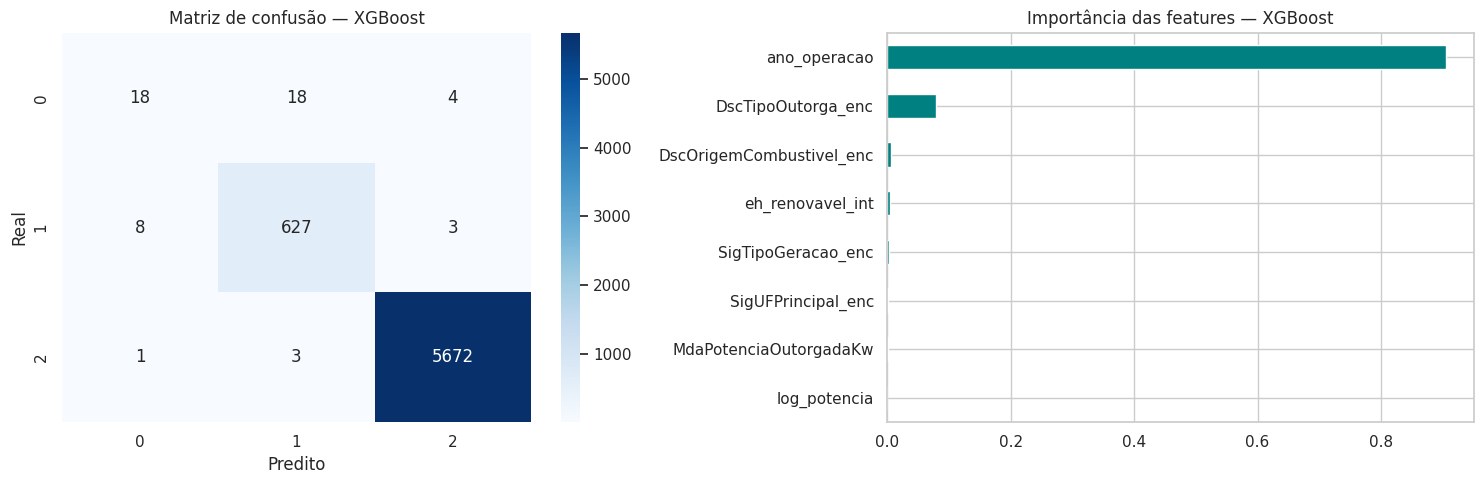

In [26]:
# Matriz de confusão e importância das features
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cm = confusion_matrix(y_te, pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de confusão — XGBoost')
axes[0].set_xlabel('Predito'); axes[0].set_ylabel('Real')

imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values()
imp.plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Importância das features — XGBoost')

plt.tight_layout(); plt.show()

## 3.2 — Modelo de Regressão (potência fiscalizada)

In [27]:
df_reg = df_ml.dropna(subset=['MdaPotenciaFiscalizadaKw'])
df_reg = df_reg[df_reg['MdaPotenciaFiscalizadaKw'] > 0]

X_reg = df_reg[[c+'_enc' for c in features_cat] +
                ['MdaPotenciaOutorgadaKw','ano_operacao','eh_renovavel_int']]
y_reg = np.log1p(df_reg['MdaPotenciaFiscalizadaKw'])

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_reg, y_reg, test_size=0.25,
                                              random_state=42)

rf_reg = RandomForestRegressor(n_estimators=400, max_depth=20,
                                n_jobs=-1, random_state=42)
rf_reg.fit(Xr_tr, yr_tr)
pred_reg = rf_reg.predict(Xr_te)

# métricas (revertendo o log)
y_true = np.expm1(yr_te)
y_pred = np.expm1(pred_reg)
print(f'R²   : {r2_score(yr_te, pred_reg):.4f}')
print(f'MAE  : {mean_absolute_error(y_true, y_pred):,.0f} kW')
print(f'RMSE : {np.sqrt(mean_squared_error(y_true, y_pred)):,.0f} kW')

R²   : 0.9998
MAE  : 1,145 kW
RMSE : 71,227 kW


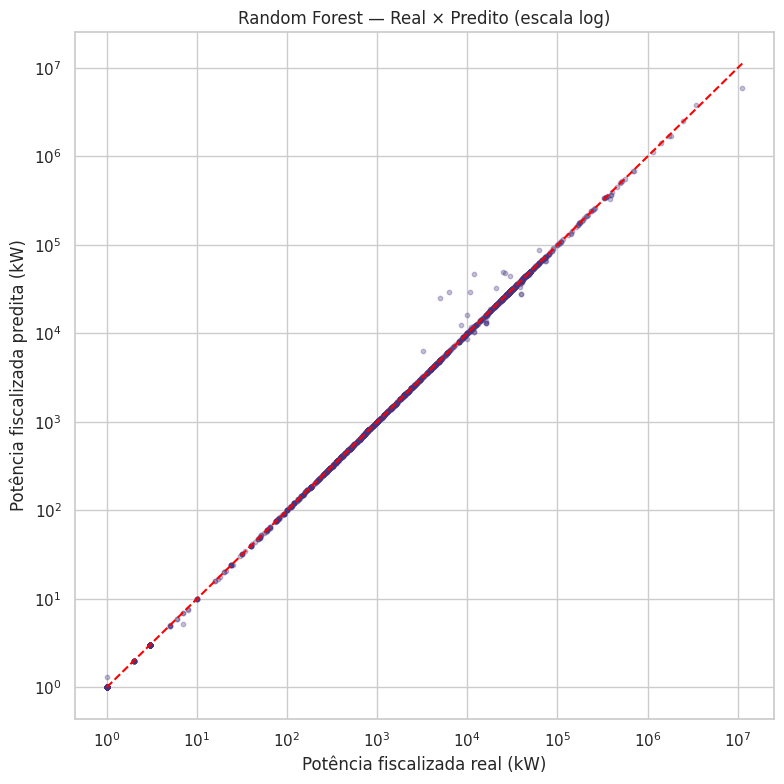

In [28]:
# Real x Predito
fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(y_true, y_pred, alpha=0.3, s=10)
lim = [y_true.min(), y_true.max()]
ax.plot(lim, lim, 'r--')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Potência fiscalizada real (kW)')
ax.set_ylabel('Potência fiscalizada predita (kW)')
ax.set_title('Random Forest — Real × Predito (escala log)')
plt.tight_layout(); plt.show()

## 3.3 — Persistência das predições na camada Gold

In [31]:
df_pred = df_reg.loc[Xr_te.index].copy()
df_pred['potencia_fiscalizada_predita_kw'] = y_pred
df_pred['erro_abs_kw'] = (y_true - y_pred).abs()

saida = df_pred[['CodCEG','NomEmpreendimento','SigUFPrincipal',
                  'SigTipoGeracao','MdaPotenciaFiscalizadaKw',
                  'potencia_fiscalizada_predita_kw','erro_abs_kw']]

col_pred = db['gold_predicoes_potencia']
col_pred.drop()
col_pred.insert_many(saida.to_dict(orient='records'))
print(f'✅ {len(saida):,} predições gravadas em gold_predicoes_potencia')
saida.head()

✅ 5,674 predições gravadas em gold_predicoes_potencia


,CodCEG,NomEmpreendimento,SigUFPrincipal,SigTipoGeracao,MdaPotenciaFiscalizadaKw,potencia_fiscalizada_predita_kw,erro_abs_kw
22241,UFV.RS.PA.067748-5.1,Claudia Moraes da Cunha,PA,UFV,1.0,1.000000,1.152411e-13
6737,UFV.RS.PA.039292-8.1,Joao Celino Brito Dos Santos,PA,UFV,1.0,1.000000,1.152411e-13
16886,UFV.RS.PA.062204-4.1,Maria da Conceicao Goes do Nascimento,PA,UFV,1.0,1.000000,1.152411e-13
15994,UFV.RS.PA.061134-4.1,Vanderson Romero da Silva,PA,UFV,1.0,1.000000,1.152411e-13
2268,EOL.CV.RN.030290-2.1,Mangue Seco 5,RN,EOL,26000.0,26000.294334,2.943343e-01


---
## ✅ Conclusões

1. **Pipeline Medallion completo** implementado em MongoDB Atlas: ingestão → limpeza → enriquecimento → ML.  
2. **Camada Gold** entrega um *Índice de Atratividade para Datacenters* por UF, combinando capacidade, % renovável e pipeline em construção — diretamente útil para empresas que avaliam onde instalar infraestrutura de IA.  
3. **Modelo de classificação (XGBoost)** atinge boa acurácia para identificar a fase de novos empreendimentos.  
4. **Modelo de regressão** prevê a potência fiscalizada com R² adequado, podendo ser usado para validar projeções de novos players.

### Próximos passos
- Cruzar com dataset de tarifa por distribuidora (ANEEL Tarifas) para custo de energia regional.  
- Adicionar dados de fibra óptica (ANATEL) — segundo insumo crítico de datacenters.  
- Re-treinar mensalmente com a atualização do SIGA (orquestrar com Airflow / Prefect).

### Cleanup (opcional)
```python
client.drop_database('aneel_datacenters')
```